In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm
# Install missing packages
!pip install lifelines
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
!pip install ecos
import cvxpy as cp
import torch
from scipy.interpolate import interp1d
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from scipy.stats import entropy
import warnings
from multiprocessing import Pool
from tqdm import tqdm
import torch.optim as optim
import time
import torch
import torch.optim as optim


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 8.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=eb5501fcfcb79bce6abc5e18346064c8c790f86e180cb8f2ffbf19d08651fdc5
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 7.4 MB/s eta 0:00:00


In [ ]:


# Function to generate T following truncated normal distribution in range [0, 1]
def generate_truncated_normal(n_samples, mean=0.5, std=0.1, lower=0, upper=1):
    """
    Generate failure times following a truncated normal distribution.

    Args:
        n_samples (int): Number of samples to generate.
        mean (float): Mean of the underlying normal distribution.
        std (float): Standard deviation of the underlying normal distribution.
        lower (float): Lower truncation point.
        upper (float): Upper truncation point.

    Returns:
        numpy array: Failure times T.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    T = truncnorm.rvs(a, b, loc=mean, scale=std, size=n_samples)
    return T

# Function to generate inspection times (intervals) following uniform distribution
def generate_inspection_intervals(n_samples, n_intervals=3):
    """
    Generate random inspection intervals.

    Args:
        n_samples (int): Number of observations.
        n_intervals (int): Number of intervals to divide [0, 1] into.

    Returns:
        numpy array: Matrix of left (L) and right (R) interval boundaries.
    """
    inspection_times = np.sort(np.random.uniform(0, 1, (n_samples, n_intervals)), axis=1)
    inspection_times = np.hstack([np.zeros((n_samples, 1)), inspection_times, np.ones((n_samples, 1))])  # Add 0 and 1 as boundaries
    return inspection_times

# Function to assign interval-censored labels
def convert_to_interval_censored_data(T, intervals):
    """
    Convert event times T into interval-censored data.

    Args:
        T (numpy array): True event times.
        intervals (numpy array): Interval boundaries.

    Returns:
        pandas DataFrame: Interval-censored data with L and R columns.
    """
    L = []
    R = []

    for i, t in enumerate(T):
        left_idx = np.searchsorted(intervals[i], t, side='right') - 1
        L.append(intervals[i][left_idx])
        R.append(intervals[i][left_idx + 1])

    data = pd.DataFrame({"L": L, "R": R})
    return data

# Define a function to compute the true density of T
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    """
    Compute the true density of a truncated normal distribution over given grid points.

    Args:
        grid_points (numpy array): Points at which to evaluate the density.
        mean (float): Mean of the underlying normal distribution.
        std (float): Standard deviation of the underlying normal distribution.
        lower (float): Lower truncation point.
        upper (float): Upper truncation point.

    Returns:
        numpy array: The true density evaluated at the grid points.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    true_density = truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)
    return true_density



In [ ]:
def midpoint_imputation(data, L_col='L', R_col='R', impute_col='W1'):
    """
    Given a DataFrame with columns [L_col, R_col],
    impute T_i^* = 0.5*(L_i + R_i).
    Overwrites (or creates) impute_col in the DataFrame.
    """
    df = data.copy()
    df[impute_col] = 0.5 * (df[L_col] + df[R_col])
    return df

def uniform_imputation(data, L_col='L', R_col='R', impute_col='W1'):
    df = data.copy()
    L_vals = df[L_col].values
    R_vals = df[R_col].values

    # Use np.random.uniform for each row
    T_imputed = np.array([
        np.random.uniform(low=L_vals[i], high=R_vals[i]) if R_vals[i] > L_vals[i]
        else L_vals[i]  # fallback if L=R
        for i in range(len(df))
    ])
    df[impute_col] = T_imputed
    return df


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

def create_hal_basis_1d(x, knots):
    """
    Simple HAL basis in 1D:
      basis_col(k) = 1{x >= knots[k]}.
    """
    x_col = x.unsqueeze(1)      # (N,1)
    knots_row = knots.unsqueeze(0)  # (1,M)
    indicator = (x_col >= knots_row).float()  # shape: (N,M)
    return indicator

def interval_nll(theta, basis_mid, delta_j, L, R, midpoints):
    """
    Compute the *negative* log-likelihood for interval-censored data.

    Args:
      theta: 1D torch tensor (K,).  theta[0] = intercept, theta[1:] = other coefs
      basis_mid: (J, K-1) basis at midpoints
      delta_j:   (J,) widths of sub-intervals
      L, R:      (n,) left & right endpoints for each subject
      midpoints: (J,) midpoints in [0,1]

    Returns:
      scalar negative log-likelihood (PyTorch graph).
    """
    n = L.shape[0]
    J = midpoints.shape[0]

    intercept = theta[0]
    coefs = theta[1:]  # shape: (K-1,)

    # log_density at each midpoint j
    log_density_j = intercept + basis_mid.matmul(coefs)  # (J,)

    # log(delta_j * exp(log_density_j))
    log_terms_j = log_density_j + torch.log(delta_j)  # shape (J,)

    # Normalizing constant => log( sum_j exp(log_terms_j) )
    logZ = torch.logsumexp(log_terms_j, dim=0)

    # Mask out midpoints not in [L_i, R_i)
    big_neg = -1e10
    # shape (n,J) => True if midpoints[j] in [L[i], R[i])
    mask = (midpoints.unsqueeze(0) >= L.unsqueeze(1)) & (midpoints.unsqueeze(0) < R.unsqueeze(1))

    # replicate log_terms_j => shape (n,J)
    log_terms_2D = log_terms_j.unsqueeze(0).expand(n, J)
    # apply mask
    masked_log_terms_2D = torch.where(mask, log_terms_2D, big_neg*torch.ones_like(log_terms_2D))
    # partial_sums[i] = logsumexp( log_terms_j ) over j in that interval
    partial_sums = torch.logsumexp(masked_log_terms_2D, dim=1)  # (n,)

    # negative log-likelihood
    # => - sum_i partial_sums[i] + n * logZ
    nll = -torch.sum(partial_sums) + n * logZ
    return nll

In [ ]:
def interval_gradient_HAL_init(data, threshold=1e-4, norm_constraint=3):
    """
    Estimate density using a nonparametric maximum likelihood estimator (NPMLE) based on data.

    Parameters:
    - data: pd.DataFrame, contains the data in column 'W1'
    - threshold: float, threshold for pruning small theta coefficients
    - norm_constraint: float, one-norm constraint for the optimization

    Returns:
    - estimated_density: np.array, estimated density values on the evaluation grid
    - grid_midpoints: np.array, midpoints of intervals on evaluation grid
    - theta_pruned: np.array, pruned theta values
    """

    # Helper function to create cumulative indicators for basis functions
    def create_cumulative_indicators_ge(series, grid_points, prefix):
        indicators_dict = {}
        id = 1
        for value in grid_points:
            id += 1
            indicator_col = f"{prefix}_ge_{value:.4f}_{id}"
            indicators_dict[indicator_col] = (series >= value).astype(int)
        return pd.DataFrame(indicators_dict, index=series.index)

    def create_basis_functions(data_long_train, grid_points, prefix='W1'):
        indicators = create_cumulative_indicators_ge(data_long_train['W1'], grid_points, prefix=prefix)
        basis_df = pd.concat([indicators], axis=1)
        return torch.tensor(basis_df.values, dtype=torch.float32)


    # Calculate sample size and determine unique grid points based on data
    n_samples = len(data)
    # Include 0 as knot points in the first order HAL to include the main terms
    grid_points_hal = np.unique(np.concatenate(([0], data['W1'].values, [1])))

    #???delta_j_hal = grid_points_hal[1:] - grid_points_hal[:-1]

    basis_tensor = create_basis_functions(data, grid_points_hal)
    b_ik = basis_tensor.detach().numpy()  # Basis for data points

    # Create evaluation grid and basis functions
    grid_eval = np.linspace(0, 1, 200)
    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})
    basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal)
    b_jk = basis_grid_tensor.numpy()  # Basis for evaluation grid

    # Set up the optimization problem for theta
    K = len(grid_points_hal) + 1
    theta = cp.Variable(K)


    first_term =  -cp.sum((theta[0] + b_ik @ theta[1:]))
    delta_j = grid_eval[1:] - grid_eval[:-1]
    log_delta_j = np.log(delta_j)
    log_density_grid = theta[0] + b_jk[:, 0:] @ theta[1:]
    log_terms = log_delta_j + log_density_grid
    log_Z = cp.log_sum_exp(log_terms)
    second_term = n_samples * log_Z

    # Define constraints using the input one-norm constraint value
    loss = first_term + second_term
    constraints = [cp.norm1(theta[1:]) <= norm_constraint]
    objective = cp.Minimize(loss)
    problem = cp.Problem(objective, constraints)
    problem.solve(solver="SCS")

    # Prune small theta coefficients and compute the estimated density
    # theta_pruned = np.where(np.abs(theta.value) > threshold, theta.value, 0)
    # non_zero_indices = np.nonzero(theta_pruned)[0]

    theta_pruned = np.copy(theta.value)
    theta_pruned[1:] = np.where(
        np.abs(theta.value[1:]) > threshold,
        theta.value[1:],
        0
    )


    non_zero_indices = np.nonzero(theta_pruned)[0]


    grid_eval = np.linspace(0, 1, 200)
    grid_points_hal_selected = grid_points_hal[non_zero_indices[1:] - 1]
    grid_eval = np.sort(np.unique(np.concatenate((grid_eval, grid_points_hal_selected))))
    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})
    basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal)
    b_jk = basis_grid_tensor.numpy()
    delta_j = grid_eval[1:] - grid_eval[:-1]

    b_jk_pruned = b_jk[:, non_zero_indices[1:] - 1]
    theta_pruned_values = theta_pruned[non_zero_indices[1:]]

    estimated_log_density = theta_pruned[0] + b_jk_pruned @ theta_pruned_values
    estimated_density = np.exp(estimated_log_density)
    estimated_density /= np.sum(estimated_density * delta_j)

    theta_value = theta_pruned[non_zero_indices]
    return {
        "theta_value": theta_value,          # store entire vector for pruned theta including intercept but get rid of 0
        "optimized_theta": theta.value,       # store entire vector for theta before prunning
        "pruned_theta": theta_pruned,          # store entire vector for pruned theta including intercept
        "estimated_density": estimated_density,
        "grid_midpoints": grid_midpoints,
        "grid_points_hal_selected": grid_points_hal_selected,
        "theta_selected": theta_pruned_values,
        "b_jk": b_jk_pruned,
        "delta_j": delta_j,
        "grid_eval": grid_eval
    }

In [ ]:

def calculate_kl_divergence(true_density, estimated_density, grid_points):
    """
    Calculate the KL divergence between the true density and estimated density.

    Args:
        true_density (numpy array): The true density values at given grid points.
        estimated_density (numpy array): The estimated density values at the same grid points.
        grid_points (numpy array): The grid points over which the densities are evaluated.

    Returns:
        float: KL divergence between the true and estimated densities.
    """
    # Compute grid spacing
    grid_spacing = np.diff(grid_points)
    grid_spacing = np.append(grid_spacing, grid_spacing[-1])  # Extend spacing for the last point

    # Create normalized copies of the input densities
    normalized_true_density = true_density / np.sum(true_density * grid_spacing)
    normalized_estimated_density = estimated_density / np.sum(estimated_density * grid_spacing)

    # Add a small epsilon to avoid issues with log or division by zero
    epsilon = 1e-10
    normalized_true_density = np.maximum(normalized_true_density, epsilon)
    normalized_estimated_density = np.maximum(normalized_estimated_density, epsilon)

    # Compute KL divergence using the grid spacing
    kl_divergence = np.sum(normalized_true_density * np.log(normalized_true_density / normalized_estimated_density) * grid_spacing)

    return kl_divergence



In [ ]:
def compute_total_log_likelihood(data, results):
    theta_param = torch.tensor(results['theta_value'], dtype=torch.float32)
    basis_mid_t = torch.tensor(results['b_jk'], dtype=torch.float32)
    delta_j = torch.tensor(results['delta_j'], dtype=torch.float32)
    L_t = torch.tensor(data["L"].values, dtype=torch.float32)
    R_t = torch.tensor(data["R"].values, dtype=torch.float32)
    midpoints_t = torch.tensor(results['grid_midpoints'], dtype=torch.float32)

    # Compute total log-likelihood
    total_log_likelihood = -interval_nll(theta_param, basis_mid_t, delta_j, L_t, R_t, midpoints_t)
    return total_log_likelihood.item()


In [ ]:
# Helper functions
def split_data_k_folds(data, k):
    """
    Split data into k folds for cross-validation and yield training and test sets.

    Parameters:
    - data: pd.DataFrame, the dataset to split
    - k: int, number of folds

    Yields:
    - data_train: pd.DataFrame, training data for the current fold
    - data_valid: pd.DataFrame, validation data for the current fold
    """
    n = len(data)
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_size = n // k

    for i in range(k):
        test_indices = indices[i * fold_size: (i + 1) * fold_size]
        train_indices = np.setdiff1d(indices, test_indices)
        data_train = data.iloc[train_indices].reset_index(drop=True)
        data_valid = data.iloc[test_indices].reset_index(drop=True)
        yield data_train, data_valid

In [ ]:
def cross_validate_interval_hal_for_lambdas(data, k, lambda_values, threshold=1e-4):

    """
    Perform k-fold cross-validation for IPCW_HAL across multiple lambda values and compute mean validation log-likelihood.

    Parameters:
    - data: pd.DataFrame, the dataset to use for cross-validation
    - k: int, number of folds
    - lambda_values: list or array, range of lambda values to test
    - threshold: float, threshold for pruning small coefficients

    Returns:
    - results: dict, containing mean validation log-likelihood for each lambda
    """
    results = {}

    for lamb in lambda_values:
        print(f"Testing lambda = {lamb} across {k}-fold cross-validation...")

        # Placeholder for validation log-likelihoods
        validation_log_likelihoods = []

        # Perform k-fold cross-validation
        for fold_idx, (data_train, data_valid) in enumerate(split_data_k_folds(data, k)):
            print(f"  Fold {fold_idx + 1}/{k}...")

            # Train the IPCW_HAL model with the current lambda value
            hal_results = interval_gradient_HAL_init(data_train, threshold=threshold, norm_constraint=lamb)

            # Compute validation log-likelihood
            log_likelihood = compute_total_log_likelihood(data_valid, hal_results)
            validation_log_likelihoods.append(log_likelihood)

        # Compute mean validation log-likelihood for this lambda
        mean_log_likelihood = np.mean(validation_log_likelihoods)

        # Store the results
        results[lamb] = {
            "mean_validation_log_likelihood": mean_log_likelihood,
            "validation_log_likelihoods": validation_log_likelihoods
        }

    return results

# Move the inner function outside to make it picklable
def compute_validation_risk_for_lambda(args):
    """
    Compute mean validation risk for a specific lambda value.
    """
    lamb, data, k, threshold = args
    validation_risks = []
    for data_train, data_valid in split_data_k_folds(data, k):
        # Train the IPCW_HAL model with the current lambda value
        hal_results = interval_gradient_HAL_init(data_train, threshold=threshold, norm_constraint=lamb)

        # Compute validation log-likelihood
        log_likelihood = compute_total_log_likelihood(data_valid, hal_results)
        validation_risks.append(log_likelihood)

    # Compute mean validation risk
    mean_risk = np.mean(validation_risks)
    return lamb, mean_risk

In [ ]:
def CV_interval_HAL(data, k, lambda_values, threshold=1e-4, n_jobs=-1):
    """
    Perform k-fold cross-validation for IPCW_HAL across multiple lambda values,
    find the best lambda (with the largest mean validation risk), and return results.

    Parameters:
    - data: pd.DataFrame, the dataset to use for cross-validation
    - k: int, number of folds
    - lambda_values: list or array, range of lambda values to test
    - threshold: float, threshold for pruning small coefficients
    - n_jobs: int, number of parallel processes to use (-1 for all available CPUs)

    Returns:
    - best_lambda: float, lambda with the largest mean validation risk
    - mean_validation_risks: dict, mean validation risk for each lambda
    """
    # Prepare arguments for parallel processing
    args = [(lamb, data, k, threshold) for lamb in lambda_values]

    # Parallelize computation across lambda values
    with Pool(processes=n_jobs if n_jobs != -1 else None) as pool:
        results = pool.map(compute_validation_risk_for_lambda, args)

    # Convert results to a dictionary
    mean_validation_risks = dict(results)

    # Find the lambda with the largest mean validation risk
    best_lambda = max(mean_validation_risks, key=mean_validation_risks.get)

    return best_lambda, mean_validation_risks

In [ ]:
# Example usage
np.random.seed(42)  # For reproducibility
n_samples = 1000
n_intervals = 5
# Generate event times (T)
T = generate_truncated_normal(n_samples)

# Generate random inspection intervals
intervals = generate_inspection_intervals(n_samples, n_intervals)

# Convert to interval-censored data
interval_censored_data = convert_to_interval_censored_data(T, intervals)

# Display the data
print(interval_censored_data.head())

# Impute
interval_censored_data = uniform_imputation(interval_censored_data)

# Display the data
print(interval_censored_data.head())

          L         R
0  0.185133  0.541901
1  0.658783  0.692277
2  0.221209  0.705575
3  0.180575  0.567945
4  0.297349  0.697420
          L         R        W1
0  0.185133  0.541901  0.416410
1  0.658783  0.692277  0.664557
2  0.221209  0.705575  0.643767
3  0.180575  0.567945  0.418078
4  0.297349  0.697420  0.360242


In [ ]:
k = 5  # Number of folds for cross-validation
lambda_values = [3, 5, 8, 10, 15, 20]
best_lambda, mean_validation_risks = CV_interval_HAL(interval_censored_data, k, lambda_values,threshold=1e-4, n_jobs=-1)
print(f"Best lambda: {best_lambda}")

Best lambda: 10


In [ ]:
best_lambda = best_lambda  # Optionally override with another choice
initial_results = interval_gradient_HAL_init(interval_censored_data, threshold=1e-4, norm_constraint=best_lambda)

In [ ]:
initial_grid_midpoints = initial_results['grid_midpoints']
true_density = compute_true_density(initial_grid_midpoints)
initial_density = initial_results['estimated_density']
# Compute the KL divergence of the IPCW estimate vs. the true density
kl_divergence_initial = calculate_kl_divergence(true_density, initial_density, initial_grid_midpoints)
print(kl_divergence_initial)

0.2709158133832567


In [ ]:
import numpy as np
import pandas as pd
import time

def precompute_global_cdf(theta_selected, grid_points_hal_selected, n_grid=500):
    """
    Precompute the density and CDF on a global grid from 0 to 1.

    Parameters:
    -----------
    theta_selected : np.ndarray
        The estimated HAL coefficients.
    grid_points_hal_selected : np.ndarray
        The knots / grid points used for the HAL basis.
    n_grid : int
        Number of points in the global evaluation grid from 0 to 1.

    Returns:
    --------
    global_grid : np.ndarray
        Sorted points in [0, 1] (length ~ n_grid + len(grid_points_hal_selected)).
    global_cdf : np.ndarray
        CDF values corresponding to each point in global_grid, scaled to end at 1.
    """
    linspace_grid = np.linspace(0, 1, n_grid)
    combined_grid = np.concatenate((linspace_grid, grid_points_hal_selected))
    global_grid = np.unique(combined_grid)
    global_grid = np.sort(global_grid)

    midpoints = (global_grid[:-1] + global_grid[1:]) / 2

    # Convert midpoints to a PyTorch tensor
    midpoints_t = torch.tensor(midpoints, dtype=torch.float32)

    # Convert knots to a PyTorch tensor
    knots_t = torch.tensor(grid_points_hal_selected, dtype=torch.float32)

    # Create HAL basis using tensors
    basis_tensor = create_hal_basis_1d(midpoints_t, knots_t)  # your HAL basis
    b_jk = basis_tensor.numpy()

    estimated_log_density = b_jk @ theta_selected
    estimated_density = np.exp(estimated_log_density)

    delta = global_grid[1:] - global_grid[:-1]

    integral = np.sum(estimated_density * delta)
    estimated_density /= integral

    cdf_values = np.cumsum(estimated_density * delta)
    cdf_values[-1] = 1.0

    global_grid_right = global_grid[1:]
    return global_grid_right, cdf_values


def truncated_invert_sampling_interval(L, R, global_grid, global_cdf, num_samples=5):
    """
    Sample from the truncated distribution on [L, R].

    Parameters:
    -----------
    L : float
        Left bound of the interval.
    R : float
        Right bound of the interval.
    global_grid : np.ndarray
        The grid over [0, 1], sorted, length N.
    global_cdf : np.ndarray
        The precomputed global CDF values at global_grid, length N.
    num_samples : int
        Number of samples to draw.

    Returns:
    --------
    samples : np.ndarray
        Array of shape (num_samples,) containing the truncated samples.
    """
    cdf_L = np.interp(L, global_grid, global_cdf)
    cdf_R = np.interp(R, global_grid, global_cdf)

    if cdf_R <= cdf_L:
        return np.full(num_samples, L)

    random_probs = cdf_L + (cdf_R - cdf_L) * np.random.rand(num_samples)
    samples = np.interp(random_probs, global_cdf, global_grid)
    return samples

def E_step(data, result, num_samples=5, n_grid=500):
    """
    E-step for interval-censored data, using truncated sampling for censored observations.

    Parameters:
    -----------
    data : pd.DataFrame
        Interval-censored data with columns ['L', 'R', 'delta'].
    result : dict
        Dictionary containing HAL model results (e.g., knots, coefficients).
    num_samples : int
        Number of samples to impute for each censored observation.
    n_grid : int
        Number of points in the global evaluation grid from 0 to 1.

    Returns:
    --------
    augmented_data : pd.DataFrame
        Augmented dataset with imputed samples for censored observations.
    """
    censored_data = data.copy()

    theta_selected = result['theta_selected']
    grid_points_hal_selected = result['grid_points_hal_selected']

    global_grid, global_cdf = precompute_global_cdf(theta_selected, grid_points_hal_selected, n_grid=n_grid)

    imputed_samples_list = []
    start_loop = time.time()

    for idx, row in censored_data.iterrows():
        L, R = row['L'], row['R']
        samples = truncated_invert_sampling_interval(L, R, global_grid, global_cdf, num_samples=num_samples)
        samples_df = pd.DataFrame({
            'L': L,
            'R': R,
            'weights': 1 / num_samples,
            'T': samples
        })
        imputed_samples_list.append(samples_df)

    end_loop = time.time()
    print(f"E-step sampling loop time: {end_loop - start_loop:.4f} sec")

    if imputed_samples_list:
        imputed_data = pd.concat(imputed_samples_list, ignore_index=True)
    else:
        imputed_data = pd.DataFrame(columns=['L', 'R', 'weights', 'T'])

    imputed_data['W1'] = imputed_data['T']
    return imputed_data




In [ ]:
import cvxpy as cp
import numpy as np
import torch
import time

def M_step(uncensored_augmented, results, old_theta, norm_constraint=20):
    start_time_m_design = time.time()

    grid_points_hal_selected = results['grid_points_hal_selected']

    # Substitute the real grid and data to be used
    grid_points_hal = grid_points_hal_selected
    uncensored_data = uncensored_augmented

    # Convert 'uncensored_data' to a PyTorch tensor
    # Assuming 'W1' column contains the relevant data for basis functions
    uncensored_t = torch.tensor(uncensored_data['W1'].values, dtype=torch.float32)

    # Convert 'grid_points_hal' to a PyTorch tensor
    knots_t = torch.tensor(grid_points_hal, dtype=torch.float32)

    # Create HAL basis using tensors
    basis_tensor = create_hal_basis_1d(uncensored_t, knots_t)  # (N, M)
    b_ik = basis_tensor.detach().numpy()  # Convert to NumPy for CVXPY

    # Evaluation grid for normalization term (full range)
    grid_eval = np.linspace(0, 1, 200)
    combined_grid = np.concatenate((grid_eval, grid_points_hal_selected))
    filtered_grid = combined_grid[combined_grid >= 0]
    filtered_grid = np.unique(filtered_grid)
    # Sort the result (optional, if you need the grid in order)
    grid_eval = np.sort(filtered_grid)

    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})

    # Convert 'data_grid' to tensors
    grid_midpoints_t = torch.tensor(grid_midpoints, dtype=torch.float32)
    knots_t_grid = torch.tensor(grid_points_hal, dtype=torch.float32)

    # Create HAL basis for grid midpoints
    basis_grid_tensor = create_hal_basis_1d(grid_midpoints_t, knots_t_grid)  # (J, M)
    b_jk = basis_grid_tensor.numpy()  # (J, M)

    end_time_m_design = time.time()
    m_step_time_design = end_time_m_design - start_time_m_design
    print(f"M-step Design Matrix Calculation time (sec): {m_step_time_design:.4f}")

    start_time_m_optimize = time.time()

    # Step 4: Set up and solve the optimization problem
    K = len(grid_points_hal) + 1
    theta = cp.Variable(K)

    # Weighted sum of basis functions
    weights_M = uncensored_data['weights'].values
    # Weighted log-likelihood terms
    n_samples_weighted = np.sum(weights_M)

    # Use cp.multiply for element-wise multiplication
    first_term = -cp.sum(cp.multiply(theta[0] + b_ik @ theta[1:], weights_M))

    # Second term with weighted normalization using evaluation grid
    delta_j = grid_eval[1:] - grid_eval[:-1]
    log_delta_j = np.log(delta_j)
    log_density_grid = theta[0] + b_jk @ theta[1:]
    log_terms = log_delta_j + log_density_grid
    log_Z = cp.log_sum_exp(log_terms)
    second_term = n_samples_weighted * log_Z

    # Total loss (weighted negative log-likelihood)
    loss = first_term + second_term

    # Set up the optimization problem with norm constraint
    constraints = [cp.norm1(theta) <= norm_constraint]
    objective = cp.Minimize(loss)
    problem = cp.Problem(objective, constraints)

    # If a good guess (theta_init) is provided, set it and use warm_start
    if old_theta is not None:
        theta.value = old_theta

    # Solve with warm_start
    #problem.solve(solver="ECOS", warm_start=True)
    problem.solve(solver="SCS", warm_start=True)

    end_time_m_optimize = time.time()
    m_step_time_optimize = end_time_m_optimize - start_time_m_optimize
    print(f"M-step CVXPY optimize time (sec): {m_step_time_optimize:.4f}")

    # Extract optimized theta values
    theta_value = theta.value
    theta_intercept = theta_value[0]
    theta_selected = theta_value[1:]

    # Compute the estimated density over the evaluation grid
    grid_eval_fine = np.linspace(0, 1, 1000)
    grid_midpoints_fine = (grid_eval_fine[:-1] + grid_eval_fine[1:]) / 2
    data_grid_fine = pd.DataFrame({'W1': grid_midpoints_fine})

    # Convert to tensors
    grid_midpoints_fine_t = torch.tensor(grid_midpoints_fine, dtype=torch.float32)
    knots_t_fine = torch.tensor(grid_points_hal, dtype=torch.float32)

    # Create HAL basis for fine grid
    basis_fine_tensor = create_hal_basis_1d(grid_midpoints_fine_t, knots_t_fine)  # (J_fine, M)
    b_jk_fine = basis_fine_tensor.numpy()  # (J_fine, M)

    delta_j_fine = grid_eval_fine[1:] - grid_eval_fine[:-1]

    estimated_log_density = theta_intercept + b_jk_fine @ theta_selected
    estimated_density = np.exp(estimated_log_density)
    estimated_density /= np.sum(estimated_density * delta_j_fine)




    # Prepare the results dictionary
    updated_results = {
        "theta_value": theta_value,                   # store entire vector for the next iteration
        "theta_selected": theta_selected,
        "theta_intercept": theta_intercept,
        "estimated_density": estimated_density,
        "grid_midpoints": grid_midpoints_fine,
        "grid_points_hal_selected": grid_points_hal_selected,
        "b_jk": b_jk_fine,
        "delta_j": delta_j_fine,
        "grid_eval": grid_eval_fine
    }

    return updated_results


In [ ]:
def EM_HAL_algorithm(data, initial_results, tolerance=1e-6, max_iterations=100, num_samples=5, norm_constraint=20):
    """
    Performs the EM algorithm for density estimation using the HAL approach.

    Parameters:
    - data: Original dataset (DataFrame) with 'T_tilde' and 'delta' columns.
    - initial_results: Initial density estimation results (from IPCW_HAL_init or similar).
    - tolerance: Convergence threshold for the change in log-likelihood.
    - max_iterations: Maximum number of iterations for the EM algorithm.
    - num_samples: Number of imputations per censored observation in the E-step.
    - norm_constraint: Norm constraint for the optimization in the M-step.

    Returns:
    - final_results: Dictionary containing the final estimated density and parameters.
    - log_likelihoods: List of log-likelihood values recorded over iterations, including the initial log-likelihood.
    """

    # Initialize variables
    iteration = 0
    previous_log_likelihood = None
    log_likelihoods = []

    # Set 'current_results' to 'initial_results' for the first iteration
    current_results = initial_results

    # **Compute the initial log-likelihood**
    initial_log_likelihood = compute_total_log_likelihood(data, current_results)
    print(f"Initial Log-Likelihood: {initial_log_likelihood}")

    # **Save the initial log-likelihood as the first element of log_likelihoods**
    log_likelihoods.append(initial_log_likelihood)

    # Begin EM algorithm loop
    while iteration < max_iterations:
        print(f"Iteration {iteration + 1}")

        ### **E-Step**
        start_time_e = time.time()

        # Use the current density estimate to perform imputations
        uncensored_augmented = E_step(data, current_results, num_samples=num_samples)

        end_time_e = time.time()
        e_step_time = end_time_e - start_time_e
        print(f"E-step time (sec): {e_step_time:.4f}")


        ### **M-Step**

        # Re-estimate the density using the augmented data
        start_time_m = time.time()

        #New M step using gradient descent
        #OR with/without warm start if using/not using old_theta through solver's warm_start=True/False
        old_theta = current_results.get("theta_value", None)
        updated_results = M_step(
            uncensored_augmented,
            current_results,
            old_theta=old_theta,           # <--- pass old_theta here
            norm_constraint=norm_constraint
        )

        end_time_m = time.time()
        m_step_time = end_time_m - start_time_m
        print(f"M-step time (sec): {m_step_time:.4f}")

        ### **Convergence Check**

        # Compute the observed data log-likelihood
        total_log_likelihood = compute_total_log_likelihood(data, updated_results)
        print(f"Total Log-Likelihood: {total_log_likelihood}")

        # score_em_iter = check_score_function(data, updated_results)
        # print("Score Updated:", np.linalg.norm(score_em_iter))

        # theta_updated_norm = np.linalg.norm(updated_results['theta_selected'] - current_results['theta_selected'])
        # print("Theta Updated:", theta_updated_norm)

        # Record the log-likelihood
        log_likelihoods.append(total_log_likelihood)

        # Check for convergence
        if previous_log_likelihood is not None:
            log_likelihood_difference = total_log_likelihood - previous_log_likelihood
            print(f"Log-Likelihood Difference: {log_likelihood_difference}")

            if abs(log_likelihood_difference) < tolerance:
                print(f"Convergence achieved at iteration {iteration + 1}")
                break

        # Update variables for the next iteration
        previous_log_likelihood = total_log_likelihood
        current_results = updated_results
        iteration += 1

    # End of EM algorithm
    print("EM algorithm completed.")

    # Final estimated density and parameters are in 'current_results'
    final_results = current_results

    return final_results, log_likelihoods

In [ ]:

final_results, log_likelihoods = EM_HAL_algorithm(
    interval_censored_data,
    initial_results,
    tolerance=0.05,
    max_iterations=100,
    num_samples=200,
    norm_constraint=best_lambda*5
)



Initial Log-Likelihood: -838.930908203125
Iteration 1
E-step sampling loop time: 0.4306 sec
E-step time (sec): 0.7342
M-step Design Matrix Calculation time (sec): 0.0575
M-step CVXPY optimize time (sec): 1.2330
M-step time (sec): 1.2999
Total Log-Likelihood: -749.5732421875
Iteration 2
E-step sampling loop time: 0.2580 sec
E-step time (sec): 0.2843
M-step Design Matrix Calculation time (sec): 0.0245
M-step CVXPY optimize time (sec): 1.5536
M-step time (sec): 1.5810
Total Log-Likelihood: -726.291015625
Log-Likelihood Difference: 23.2822265625
Iteration 3
E-step sampling loop time: 0.2530 sec
E-step time (sec): 0.2771
M-step Design Matrix Calculation time (sec): 0.0167
M-step CVXPY optimize time (sec): 1.9459
M-step time (sec): 1.9672
Total Log-Likelihood: -718.298828125
Log-Likelihood Difference: 7.9921875
Iteration 4
E-step sampling loop time: 0.2543 sec
E-step time (sec): 0.2786
M-step Design Matrix Calculation time (sec): 0.0149
M-step CVXPY optimize time (sec): 3.8532
M-step time (s

/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


E-step sampling loop time: 0.3246 sec
E-step time (sec): 0.3670
M-step Design Matrix Calculation time (sec): 0.0345
WARNING - large complementary slackness residual: 0.009551
M-step CVXPY optimize time (sec): 15.3743
M-step time (sec): 15.4174
Total Log-Likelihood: -712.14453125
Log-Likelihood Difference: 1.0849609375
Iteration 7


/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


E-step sampling loop time: 0.4999 sec
E-step time (sec): 0.5272
M-step Design Matrix Calculation time (sec): 0.0147
WARNING - large complementary slackness residual: 0.020244
M-step CVXPY optimize time (sec): 1.9594
M-step time (sec): 1.9783
Total Log-Likelihood: -711.537109375
Log-Likelihood Difference: 0.607421875
Iteration 8
E-step sampling loop time: 0.2556 sec
E-step time (sec): 0.2794
M-step Design Matrix Calculation time (sec): 0.0149


...

/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


E-step sampling loop time: 0.2674 sec
E-step time (sec): 0.2953
M-step Design Matrix Calculation time (sec): 0.0138


/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


M-step CVXPY optimize time (sec): 14.4168
M-step time (sec): 14.4351
Total Log-Likelihood: -709.048828125
Log-Likelihood Difference: 0.05859375
Iteration 21
E-step sampling loop time: 0.2693 sec
E-step time (sec): 0.2948
M-step Design Matrix Calculation time (sec): 0.0148
M-step CVXPY optimize time (sec): 14.3306
M-step time (sec): 14.3483
Total Log-Likelihood: -709.015625
Log-Likelihood Difference: 0.033203125
Convergence achieved at iteration 21
EM algorithm completed.


/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


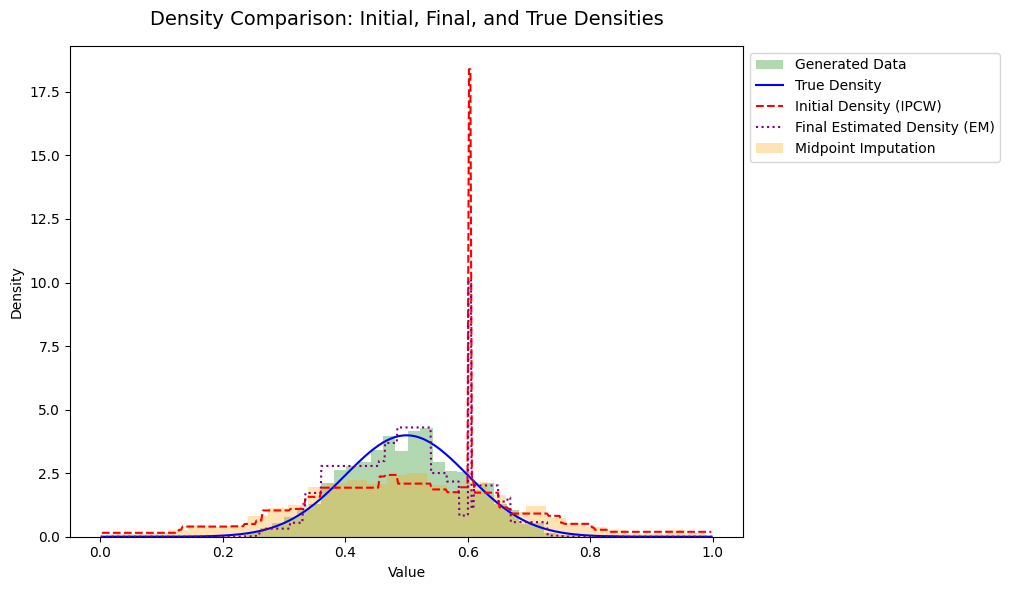

In [ ]:
# Parameters for the true density (truncated normal distribution)
grid_points = initial_results['grid_midpoints']
# Compute the true density
true_density = compute_true_density(grid_points)

# Use placeholders for initial and final results from IPCW and EM algorithms
initial_density = initial_results['estimated_density']
initial_grid_midpoints = initial_results['grid_midpoints']

final_density = final_results['estimated_density']
final_grid_midpoints = final_results['grid_midpoints']

# Event times T and observed times T_tilde from previous data generation
# Increase the figure width to give more room to the plot
plt.figure(figsize=(12, 6))

# Plot the histogram of the generated event times T
plt.hist(T, bins=30, density=True, alpha=0.3, color='green', label="Generated Data")


# Plot the true density
plt.plot(grid_points, true_density, label="True Density", color="blue", linewidth=1.5)

# Plot the initial estimated density from IPCW
plt.plot(initial_grid_midpoints, initial_density, label="Initial Density (IPCW)", color="red", linestyle="--", linewidth=1.5)

# Plot the final estimated density from the EM algorithm
plt.plot(final_grid_midpoints, final_density, label="Final Estimated Density (EM)", color="purple", linestyle=":", linewidth=1.5)

midtimes_impute= interval_censored_data['W1'].values
plt.hist(midtimes_impute, bins=30, density=True, alpha=0.3, color='orange', label="Midpoint Imputation")

# Add labels, title, and legend with smaller font size
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Density Comparison: Initial, Final, and True Densities", fontsize=14, pad=15)

# Place the legend outside the plot area
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)

# Adjust the layout to avoid skewing
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()


In [ ]:
def get_estimated_density_at_point(point, estimated_results):
    """
    Get the estimated density value at a specific point using step function interpolation.

    Args:
        point (float): Point at which to evaluate the density
        estimated_results (dict): Dictionary containing estimation results

    Returns:
        float: Estimated density value at the specified point
    """
    grid_edges = estimated_results['grid_eval']
    estimated_density = estimated_results['estimated_density']

    # Find which bin the point falls into
    for i in range(len(grid_edges)-1):
        if grid_edges[i] <= point < grid_edges[i+1]:
            return estimated_density[i]

    # Handle edge cases
    if point <= grid_edges[0]:
        return estimated_density[0]
    return estimated_density[-1]

def evaluate_density_at_points(points, initial_results, final_results):
    """
    Evaluate density estimates at specified points and compare with true density.
    """
    true_density = compute_true_density(points)

    evaluation = {
        'points': points,
        'initial_est': [],
        'final_est': [],
        'true_val': []
    }

    for point in points:
        # Get estimated densities
        initial_val = get_estimated_density_at_point(point, initial_results)
        final_val = get_estimated_density_at_point(point, final_results)

        # Get true density value for this point
        true_val = true_density[np.where(points == point)[0][0]]

        # Calculate differences (estimated - true)
        evaluation['initial_est'].append(initial_val)
        evaluation['final_est'].append(final_val)
        evaluation['true_val'].append(true_val)

    # Convert lists to numpy arrays
    evaluation['initial_est'] = np.array(evaluation['initial_est'])
    evaluation['final_est'] = np.array(evaluation['final_est'])
    evaluation['true_val'] = np.array(evaluation['true_val'])

    return evaluation


In [ ]:
# Create 20 evenly spaced points from 0.02 to 0.98
evaluation_points = np.linspace(0.02, 0.98, 20)
results = evaluate_density_at_points(evaluation_points, initial_results, final_results)

# Print results
print("\nPointwise Evaluation Results:")
print("Point | True Value | Initial Est | Final Est")
print("-" * 55)
for i, point in enumerate(evaluation_points):
    print(f"{point:.2f}  |  {results['true_val'][i]:9.4f}  |  {results['initial_est'][i]:9.4f}  |  {results['final_est'][i]:9.4f}")


Pointwise Evaluation Results:
Point | True Value | Initial Est | Final Est
-------------------------------------------------------
0.02  |     0.0000  |     0.1532  |     0.0000
0.07  |     0.0004  |     0.1532  |     0.0000
0.12  |     0.0030  |     0.1532  |     0.0000
0.17  |     0.0181  |     0.3989  |     0.0009
0.22  |     0.0839  |     0.4103  |     0.0047
0.27  |     0.3008  |     1.0332  |     0.3176
0.32  |     0.8353  |     1.0940  |     0.5485
0.37  |     1.7965  |     1.9290  |     2.7836
0.42  |     2.9935  |     1.9290  |     2.7836
0.47  |     3.8641  |     2.4312  |     3.6881
0.53  |     3.8641  |     2.0887  |     4.2986
0.58  |     2.9935  |     1.7505  |     2.1719
0.63  |     1.7965  |     1.7323  |     2.0179
0.68  |     0.8353  |     0.9117  |     0.5732
0.73  |     0.3008  |     0.9117  |     0.5732
0.78  |     0.0839  |     0.5065  |     0.0006
0.83  |     0.0181  |     0.2735  |     0.0008
0.88  |     0.0030  |     0.1934  |     0.0008
0.93  |     0.0004  | 

In [ ]:
def run_single_experiment(seed):
    """
    Run a single experiment with given seed
    """
    np.random.seed(seed)
    # Generate data
    n_samples = 1000
    n_intervals = 5
    # Generate event times (T)
    T = generate_truncated_normal(n_samples)

    # Generate random inspection intervals
    intervals = generate_inspection_intervals(n_samples, n_intervals)

    # Convert to interval-censored data
    data = convert_to_interval_censored_data(T, intervals)
    data = uniform_imputation(data)

    # Cross validation and initial estimation
    k = 5
    lambda_values = [3, 5, 8, 10, 15, 20]
    best_lambda, _ = CV_interval_HAL(data, k, lambda_values, threshold=1e-4, n_jobs=-1)

    # Get initial and final estimates
    initial_results = interval_gradient_HAL_init(data, threshold=1e-4, norm_constraint=best_lambda)
    final_results, _ = EM_HAL_algorithm(
        data,
        initial_results,
        tolerance=0.05,
        max_iterations=20,
        num_samples=400,
        norm_constraint=5 * best_lambda
    )

    return initial_results, final_results

def run_repeated_experiments(n_experiments=10):
    """
    Run multiple experiments and return results as a single DataFrame
    """
    # Evaluation points
    evaluation_points = np.linspace(0.02, 0.98, 20)

    # Arrays to store results
    initial_estimates = np.zeros((n_experiments, len(evaluation_points)))
    final_estimates = np.zeros((n_experiments, len(evaluation_points)))

    # Run experiments
    for i in range(n_experiments):
        print(f"Running experiment {i+1}/{n_experiments}")
        seed = 12776 + i  # Different seed for each experiment
        initial_results, final_results = run_single_experiment(seed)

        # Evaluate at points
        evaluation = evaluate_density_at_points(evaluation_points, initial_results, final_results)
        initial_estimates[i, :] = evaluation['initial_est']
        final_estimates[i, :] = evaluation['final_est']

    # Get true values
    true_values = compute_true_density(evaluation_points)

    # Calculate statistics
    initial_bias = np.mean(initial_estimates, axis=0) - true_values
    final_bias = np.mean(final_estimates, axis=0) - true_values

    initial_variance = np.var(initial_estimates, axis=0)
    final_variance = np.var(final_estimates, axis=0)

    initial_mse = np.mean((initial_estimates - true_values.reshape(1, -1)) ** 2, axis=0)
    final_mse = np.mean((final_estimates - true_values.reshape(1, -1)) ** 2, axis=0)

    # Create single DataFrame with results
    results_df = pd.DataFrame({
        'points': evaluation_points,
        'initial_bias': initial_bias,
        'initial_variance': initial_variance,
        'initial_mse': initial_mse,
        'final_bias': final_bias,
        'final_variance': final_variance,
        'final_mse': final_mse
    })

    return results_df

def print_statistics(results_df):
    """
    Print the statistics from DataFrame
    """
    print("\nStatistics at each evaluation point:")
    print("-" * 100)
    print(results_df.to_string(float_format=lambda x: '{:.4f}'.format(x)))

    # Print average statistics
    print("\nAverage Statistics:")
    print("-" * 60)
    print(f"Initial estimator:")
    print(f"  Average absolute bias: {np.mean(np.abs(results_df['initial_bias'])):.4f}")
    print(f"  Average variance: {np.mean(results_df['initial_variance']):.4f}")
    print(f"  Average MSE: {np.mean(results_df['initial_mse']):.4f}")
    print(f"\nFinal estimator:")
    print(f"  Average absolute bias: {np.mean(np.abs(results_df['final_bias'])):.4f}")
    print(f"  Average variance: {np.mean(results_df['final_variance']):.4f}")
    print(f"  Average MSE: {np.mean(results_df['final_mse']):.4f}")

def plot_statistics(results_df, save_path=None):
    """
    Plot bias, variance, and MSE comparisons using DataFrame and optionally save plots

    Args:
        results_df: DataFrame with statistics
        save_path: str, path where to save the plots (without extension)
                  If None, plots will only be displayed
    """
    points = results_df['points']

    # Create separate plots for each statistic
    # Bias plot
    plt.figure(figsize=(10, 6))
    plt.plot(points, results_df['initial_bias'], label='Initial', marker='o')
    plt.plot(points, results_df['final_bias'], label='Final', marker='o')
    plt.title('Bias Comparison')
    plt.xlabel('Points')
    plt.ylabel('Bias')
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(f"{save_path}_bias.pdf")

    # Variance plot
    plt.figure(figsize=(10, 6))
    plt.plot(points, results_df['initial_variance'], label='Initial', marker='o')
    plt.plot(points, results_df['final_variance'], label='Final', marker='o')
    plt.title('Variance Comparison')
    plt.xlabel('Points')
    plt.ylabel('Variance')
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(f"{save_path}_variance.pdf")

    # MSE plot
    plt.figure(figsize=(10, 6))
    plt.plot(points, results_df['initial_mse'], label='Initial', marker='o')
    plt.plot(points, results_df['final_mse'], label='Final', marker='o')
    plt.title('MSE Comparison')
    plt.xlabel('Points')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(f"{save_path}_mse.pdf")

Running experiment 1/2
Initial Log-Likelihood: -814.25830078125
Iteration 1
E-step sampling loop time: 0.3025 sec
E-step time (sec): 0.5221
M-step Design Matrix Calculation time (sec): 0.0625
M-step CVXPY optimize time (sec): 2.8595
M-step time (sec): 2.9331
Total Log-Likelihood: -724.02099609375
Iteration 2
E-step sampling loop time: 0.2938 sec
E-step time (sec): 0.3254
M-step Design Matrix Calculation time (sec): 0.0697
M-step CVXPY optimize time (sec): 3.4838
M-step time (sec): 3.5810
Total Log-Likelihood: -700.8271484375
Log-Likelihood Difference: 23.19384765625
Iteration 3
E-step sampling loop time: 0.3935 sec
E-step time (sec): 0.4396
M-step Design Matrix Calculation time (sec): 0.0985
M-step CVXPY optimize time (sec): 3.9960
M-step time (sec): 4.1069
Total Log-Likelihood: -693.90673828125
Log-Likelihood Difference: 6.92041015625
Iteration 4
E-step sampling loop time: 0.2875 sec
E-step time (sec): 0.3188
M-step Design Matrix Calculation time (sec): 0.0707
M-step CVXPY optimize ti

/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


E-step sampling loop time: 0.6010 sec
E-step time (sec): 0.6539
M-step Design Matrix Calculation time (sec): 0.1003
WARNING - large complementary slackness residual: 0.021052
M-step CVXPY optimize time (sec): 5.3976
M-step time (sec): 5.5102
Total Log-Likelihood: -689.45751953125
Log-Likelihood Difference: 0.35302734375
Iteration 8
E-step sampling loop time: 0.3195 sec
E-step time (sec): 0.3563
M-step Design Matrix Calculation time (sec): 0.0755
WARNING - large complementary slackness residual: 0.038529
M-step CVXPY optimize time (sec): 18.0172
M-step time (sec): 18.1053
Total Log-Likelihood: -689.2431640625
Log-Likelihood Difference: 0.21435546875
Iteration 9


/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


E-step sampling loop time: 0.3061 sec
E-step time (sec): 0.3349
M-step Design Matrix Calculation time (sec): 0.0632
WARNING - large complementary slackness residual: 0.044618
M-step CVXPY optimize time (sec): 20.7730
M-step time (sec): 20.8478
Total Log-Likelihood: -689.00244140625
Log-Likelihood Difference: 0.24072265625
Iteration 10


...

E-step sampling loop time: 0.6146 sec
E-step time (sec): 0.6751
M-step Design Matrix Calculation time (sec): 0.1132
M-step CVXPY optimize time (sec): 4.1369
M-step time (sec): 4.2623
Total Log-Likelihood: -710.28076171875
Log-Likelihood Difference: 0.2255859375
Iteration 9
E-step sampling loop time: 0.2965 sec
E-step time (sec): 0.3228
M-step Design Matrix Calculation time (sec): 0.0654
WARNING - large complementary slackness residual: 0.049608
M-step CVXPY optimize time (sec): 19.2283
M-step time (sec): 19.3054
Total Log-Likelihood: -710.1826171875
Log-Likelihood Difference: 0.09814453125
Iteration 10


/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


E-step sampling loop time: 0.2971 sec
E-step time (sec): 0.3287
M-step Design Matrix Calculation time (sec): 0.0676
M-step CVXPY optimize time (sec): 5.5098
M-step time (sec): 5.5901
Total Log-Likelihood: -709.958984375
Log-Likelihood Difference: 0.2236328125
Iteration 11
E-step sampling loop time: 0.2862 sec
E-step time (sec): 0.3260
M-step Design Matrix Calculation time (sec): 0.0587
WARNING - large complementary slackness residual: 0.048293
M-step CVXPY optimize time (sec): 17.8170
M-step time (sec): 17.8882
Total Log-Likelihood: -709.91162109375
Log-Likelihood Difference: 0.04736328125
Convergence achieved at iteration 11
EM algorithm completed.


/usr/local/lib/python3.11/dist-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



Statistics at each evaluation point:
----------------------------------------------------------------------------------------------------
    points  initial_bias  initial_variance  initial_mse  final_bias  final_variance  final_mse
0   0.0200        0.1658            0.0007       0.0282      0.0004          0.0000     0.0000
1   0.0705        0.1655            0.0007       0.0281      0.0000          0.0000     0.0000
2   0.1211        0.2355            0.0097       0.0652      0.0003          0.0000     0.0000
3   0.1716        0.3430            0.0014       0.1190      0.0116          0.0006     0.0008
4   0.2221        0.5238            0.0117       0.2860      0.0246          0.0057     0.0063
5   0.2726        0.4318            0.0003       0.1867     -0.0892          0.0008     0.0087
6   0.3232        0.3059            0.0003       0.0938     -0.2197          0.0154     0.0637
7   0.3737       -0.2526            0.0023       0.0661     -0.2284          0.0125     0.0647
8   0.

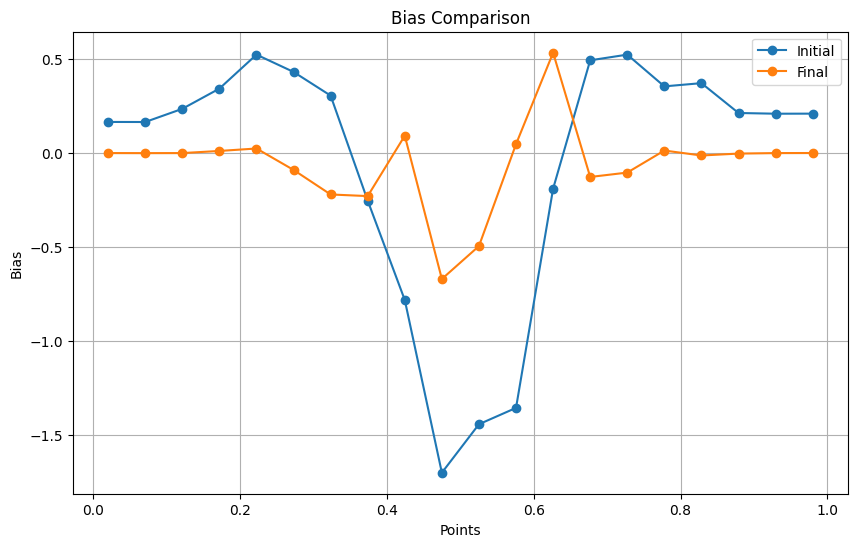

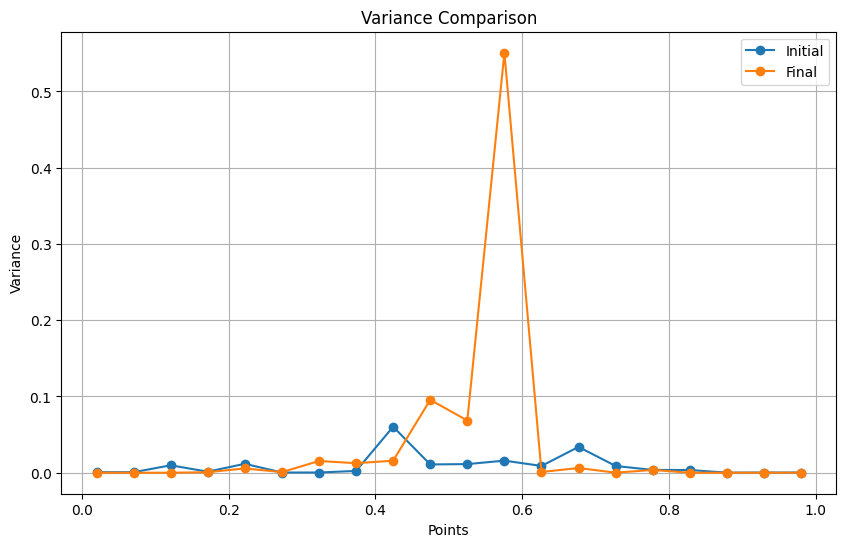

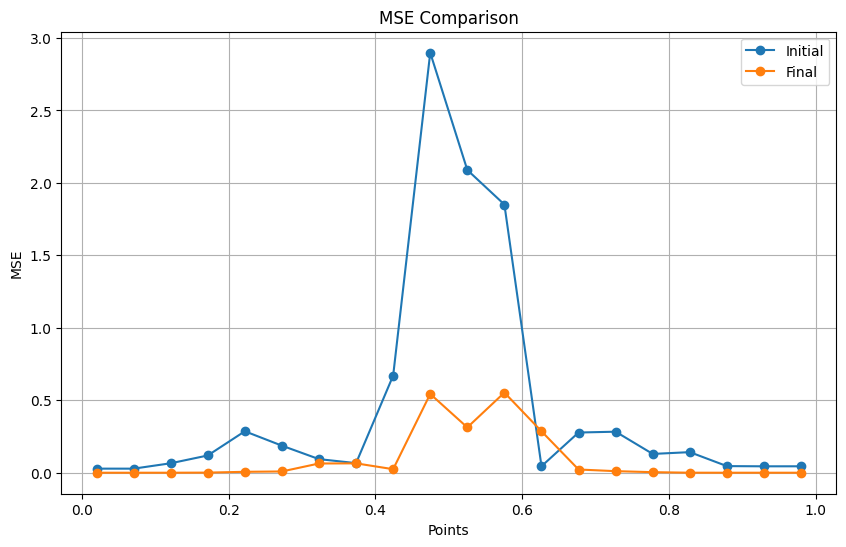

In [ ]:
# Set random seed for reproducibility
np.random.seed(12776)

# Run experiments and get results
results_df = run_repeated_experiments(n_experiments=2)

# Save DataFrame
results_df.to_csv('density_estimation_stats.csv', index=False)

# Create and save plots
plot_statistics(results_df, save_path='density_estimation')

# Print summary statistics
print_statistics(results_df)